# Phase 14 — FaceForensics++ Domain Adaptation

**Objective:** Fine-tune the trained Xception dual-stream model on FaceForensics++ C23 compressed video frames. The model currently detects Stable Diffusion v1.4 artifacts from CIFAKE training. This phase teaches it to also detect GAN face-swap artifacts — the second category of AI-generated fakes specified in the proposal. The C23 (lightly compressed) version is used because it retains more artifact detail than C40, while still representing the compression encountered in real-world sharing.

## Context: Why This Phase Exists and Why C23

The CIFAKE-trained model predicts REAL on many real-world deepfakes. This is a domain shift problem. CIFAKE contains diffusion-model objects (cars, ships, animals). FaceForensics++ contains face-swap videos made with DeepFakes, FaceSwap, Face2Face, FaceShifter, NeuralTextures, and DeepFakeDetection generators.

The C23 version applies moderate JPEG compression (quality factor 23). This matters because:
- C23 retains meaningful GAN-grid and blending artifacts that C40 destroys
- It is the standard benchmark compression used in FF++ papers
- A model trained on C23 generalises better to C40 than the reverse

**Dataset format:** FF++ ships as raw `.mp4` video files, not images. This notebook includes a **frame extraction pipeline** that:
1. Reads the `original/` folder → extracts frames → saves as `REAL`
2. Reads each manipulation folder (Deepfakes, Face2Face, FaceSwap, FaceShifter, NeuralTextures, DeepFakeDetection) → saves as `FAKE`
3. Uses the official CSV split files to assign videos to train/test correctly
4. Applies face detection (Haar cascade) to crop only the face region from each frame

**Training strategy:** Domain adaptation — not retraining from scratch.
- Load the best Xception dual-stream checkpoint from Phase 13
- Freeze all layers except the top 10
- Fine-tune at lr=1e-6 for a small number of epochs
- The model retains CIFAKE knowledge while adapting to face-swap patterns

**After extraction the dataset will be organised as:**
```
ff_frames/
    train/
        REAL/    ← original video frames (face-cropped)
        FAKE/    ← manipulated video frames (face-cropped)
    test/
        REAL/
        FAKE/
```

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tqdm.notebook import tqdm
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import Sequence
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

2026-06-10 12:12:32.341908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781093552.815291      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781093552.927076      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781093554.157342      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781093554.157383      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781093554.157386      58 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [5]:
# ── CIFAKE model from Phase 13 ────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/models/jasminsultanashimu/p-13-final-model/keras/default/1/xception_dual_final.keras"

# ── FF++ C23 raw video dataset (Kaggle input) ──────────────────────────────
# This is where  uploaded dataset lives — the folder containing
# FaceForensics++_C23/ with original/, Deepfakes/, Face2Face/, etc.
FF_RAW_BASE = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

# Sub-directories inside FF_RAW_BASE
FF_ORIGINAL_DIR = os.path.join(FF_RAW_BASE, "original")          # REAL videos
FF_FAKE_DIRS    = [
    os.path.join(FF_RAW_BASE, "Deepfakes"),
    os.path.join(FF_RAW_BASE, "Face2Face"),
    os.path.join(FF_RAW_BASE, "FaceSwap"),
    os.path.join(FF_RAW_BASE, "FaceShifter"),
    os.path.join(FF_RAW_BASE, "NeuralTextures"),
    os.path.join(FF_RAW_BASE, "DeepFakeDetection"),
]  # All manipulation types → label FAKE

# CSV split files (official train/val/test splits)
FF_CSV_DIR      = os.path.join(FF_RAW_BASE, "csv")

# ── Extracted frames will be written here ─────────────────────────────────
# This directory is created at runtime in /kaggle/working (writable)
FF_FRAMES_BASE  = "/kaggle/working/ff_frames"
FF_TRAIN        = os.path.join(FF_FRAMES_BASE, "train")
FF_TEST         = os.path.join(FF_FRAMES_BASE, "test")

# ── Frame extraction settings ──────────────────────────────────────────────
FRAMES_PER_VIDEO    = 10    # Extract N evenly-spaced frames per video
                            # Increase to 20-30 for more data (slower)
USE_FACE_CROP       = True  # Crop to face bounding box (recommended)
FACE_CROP_MARGIN    = 0.20  # 20 % padding around detected face
MIN_FACE_SIZE       = (60, 60)  # Discard very small detections

# ── Training settings ─────────────────────────────────────────────────────
RESULT_DIR     = "/kaggle/working/results/ffpp_adaptation"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
MODEL_DIR      = "/kaggle/working/models"

os.makedirs(RESULT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,      exist_ok=True)

IMG_SIZE     = (299, 299)
BATCH_SIZE   = 16
EPOCHS_ADAPT = 10
CLASS_MAP    = {"FAKE": 1, "REAL": 0}

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Verify Model and Dataset Paths

In [6]:
# Verify Phase 13 model
if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    print(f"✓ Model found  : {MODEL_PATH}  ({size_mb:.1f} MB)")
else:
    print("✗ Model NOT FOUND — run Phase 13 first and download xception_dual_final.keras")

# Verify raw video directories
print("\n── Raw Video Dataset ───────────────────────────────────")
if os.path.exists(FF_ORIGINAL_DIR):
    orig_count = len([f for f in os.listdir(FF_ORIGINAL_DIR) if f.endswith('.mp4')])
    print(f"✓ original/           : {orig_count} videos (REAL)")
else:
    print(f"✗ original/ NOT FOUND — check FF_RAW_BASE path: {FF_RAW_BASE}")

for fdir in FF_FAKE_DIRS:
    name = os.path.basename(fdir)
    if os.path.exists(fdir):
        cnt = len([f for f in os.listdir(fdir) if f.endswith('.mp4')])
        print(f"✓ {name:<22}: {cnt} videos (FAKE)")
    else:
        print(f"✗ {name:<22}: NOT FOUND")

# Verify CSV files
print("\n── CSV Split Files ─────────────────────────────────────")
if os.path.exists(FF_CSV_DIR):
    csvs = [f for f in os.listdir(FF_CSV_DIR) if f.endswith('.csv')]
    for c in sorted(csvs):
        print(f"  {c}")
else:
    print(f"✗ csv/ NOT FOUND — will fall back to random 80/20 split")

# Check if frames already extracted
print("\n── Extracted Frames (if already done) ──────────────────")
for split, path in [("train", FF_TRAIN), ("test", FF_TEST)]:
    if os.path.exists(path):
        r = len(os.listdir(os.path.join(path, "REAL"))) if os.path.exists(os.path.join(path, "REAL")) else 0
        f = len(os.listdir(os.path.join(path, "FAKE"))) if os.path.exists(os.path.join(path, "FAKE")) else 0
        print(f"  {split}: REAL={r}  FAKE={f}")
    else:
        print(f"  {split}: not yet extracted")

✓ Model found  : /kaggle/input/models/jasminsultanashimu/p-13-final-model/keras/default/1/xception_dual_final.keras  (192.7 MB)

── Raw Video Dataset ───────────────────────────────────
✓ original/           : 1000 videos (REAL)
✓ Deepfakes             : 1000 videos (FAKE)
✓ Face2Face             : 1000 videos (FAKE)
✓ FaceSwap              : 1000 videos (FAKE)
✓ FaceShifter           : 1000 videos (FAKE)
✓ NeuralTextures        : 1000 videos (FAKE)
✓ DeepFakeDetection     : 1000 videos (FAKE)

── CSV Split Files ─────────────────────────────────────
  DeepFakeDetection.csv
  Deepfakes.csv
  FF++_Metadata.csv
  FF++_Metadata_Shuffled.csv
  Face2Face.csv
  FaceShifter.csv
  FaceSwap.csv
  Mean_Data.csv
  NeuralTextures.csv
  original.csv

── Extracted Frames (if already done) ──────────────────
  train: not yet extracted
  test: not yet extracted


## Step 1 — Extract Frames from Videos

FF++ ships as `.mp4` files. Before training we must extract individual frames and organise them into `REAL/` and `FAKE/` folders split by train/test.

**Strategy:**
- Use the official `FF++_Metadata.csv` to get the train/test split (column `split`)
- If the CSV is not available, fall back to a deterministic 80/20 split on video filenames
- For each video, sample `FRAMES_PER_VIDEO` evenly-spaced frames
- Apply Haar-cascade face detection and crop to the face region (adds `FACE_CROP_MARGIN` padding)
- Frames where no face is detected are saved full-frame as fallback
- **Skip this cell if you have already extracted frames** (the verify cell above will show non-zero counts)

In [7]:
def get_train_test_split_from_csv(csv_dir):
    """
    Parse FF++_Metadata.csv to get the official train/test video split.
    Returns two sets of video stem IDs: (train_ids, test_ids)
    """
    meta_path = os.path.join(csv_dir, "FF++_Metadata.csv")
    if not os.path.exists(meta_path):
        # Try shuffled version
        meta_path = os.path.join(csv_dir, "FF++_Metadata_Shuffled.csv")
    if not os.path.exists(meta_path):
        print("  No metadata CSV found — using random 80/20 split")
        return None, None

    df = pd.read_csv(meta_path)
    print(f"  Loaded {meta_path} — {len(df)} rows")
    print(f"  Columns: {list(df.columns)}")

    # Common column names in FF++ CSVs
    split_col = None
    for col in ['split', 'Split', 'set', 'Set', 'partition']:
        if col in df.columns:
            split_col = col
            break

    id_col = None
    for col in ['id', 'Id', 'video_id', 'filename', 'name']:
        if col in df.columns:
            id_col = col
            break

    if split_col is None or id_col is None:
        print(f"  Cannot find split or id column — using random 80/20 split")
        return None, None

    train_ids = set(df[df[split_col].str.lower().isin(['train'])][id_col].astype(str))
    test_ids  = set(df[df[split_col].str.lower().isin(['test', 'val', 'validation'])][id_col].astype(str))
    print(f"  Train videos: {len(train_ids)}  |  Test videos: {len(test_ids)}")
    return train_ids, test_ids


def get_face_detector():
    """Load OpenCV Haar cascade for fast face detection."""
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    return cv2.CascadeClassifier(cascade_path)


def crop_face(frame, detector, margin=0.20, min_size=(60, 60)):
    """
    Detect and crop the largest face in a frame.
    Returns cropped face or None if no face found.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=4,
        minSize=min_size, flags=cv2.CASCADE_SCALE_IMAGE
    )
    if len(faces) == 0:
        return None

    # Pick largest face by area
    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
    H, W = frame.shape[:2]
    pad_x, pad_y = int(w * margin), int(h * margin)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(W, x + w + pad_x)
    y2 = min(H, y + h + pad_y)
    return frame[y1:y2, x1:x2]


def extract_frames_from_video(video_path, output_dir, label, stem,
                              frames_per_video=10, detector=None,
                              use_face_crop=True, margin=0.20):
    """
    Extract `frames_per_video` evenly-spaced frames from a video file.
    Saves as JPEG into output_dir/label/.
    Returns number of frames saved.
    """
    out_cls_dir = os.path.join(output_dir, label)
    os.makedirs(out_cls_dir, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return 0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return 0

    # Evenly-spaced frame indices
    frame_indices = np.linspace(0, total_frames - 1, frames_per_video, dtype=int)
    saved = 0

    for fi in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret or frame is None:
            continue

        if use_face_crop and detector is not None:
            cropped = crop_face(frame, detector, margin=margin)
            if cropped is not None:
                frame = cropped   # Use face crop
            # else: fall back to full frame

        out_path = os.path.join(out_cls_dir, f"{stem}_f{fi:05d}.jpg")
        cv2.imwrite(out_path, frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved += 1

    cap.release()
    return saved


def run_extraction(skip_if_exists=True):
    """
    Main extraction driver.
    Set skip_if_exists=False to force re-extraction even if frames already exist.
    """
    # Quick check — skip if already extracted
    if skip_if_exists:
        real_train = os.path.join(FF_TRAIN, "REAL")
        if os.path.exists(real_train) and len(os.listdir(real_train)) > 100:
            print("Frames already extracted. Set skip_if_exists=False to re-run.")
            return

    print("Loading face detector...")
    detector = get_face_detector() if USE_FACE_CROP else None

    print("Reading train/test split from CSV...")
    train_ids, test_ids = get_train_test_split_from_csv(FF_CSV_DIR)

    def assign_split(stem):
        """Assign a video stem to train or test based on CSV or 80/20 hash."""
        if train_ids is not None:
            # Try exact match and prefix match (e.g. '000' matches '000_003')
            base = stem.split('_')[0]  # '000' from '000_003'
            if stem in test_ids or base in test_ids:
                return "test"
            return "train"
        else:
            # Deterministic 80/20 fallback using hash
            return "test" if (hash(stem) % 10) < 2 else "train"

    stats = {"train": {"REAL": 0, "FAKE": 0}, "test": {"REAL": 0, "FAKE": 0}}

    # ── Extract REAL frames from original/ ────────────────────────────────
    print("\nExtracting REAL frames from original/ ...")
    orig_videos = sorted(Path(FF_ORIGINAL_DIR).glob("*.mp4"))
    for vpath in tqdm(orig_videos, desc="REAL videos"):
        stem   = vpath.stem                     # e.g. '000'
        split  = assign_split(stem)
        outdir = FF_TRAIN if split == "train" else FF_TEST
        n = extract_frames_from_video(
            vpath, outdir, label="REAL", stem=stem,
            frames_per_video=FRAMES_PER_VIDEO,
            detector=detector, use_face_crop=USE_FACE_CROP,
            margin=FACE_CROP_MARGIN
        )
        stats[split]["REAL"] += n

    # ── Extract FAKE frames from each manipulation directory ───────────────
    for fake_dir in FF_FAKE_DIRS:
        method = os.path.basename(fake_dir)
        fake_videos = sorted(Path(fake_dir).glob("*.mp4"))
        print(f"\nExtracting FAKE frames from {method}/ ({len(fake_videos)} videos) ...")
        for vpath in tqdm(fake_videos, desc=method):
            stem   = vpath.stem                  # e.g. '000_003'
            # Use source ID for split assignment (first part before '_')
            split  = assign_split(stem.split('_')[0])
            outdir = FF_TRAIN if split == "train" else FF_TEST
            n = extract_frames_from_video(
                vpath, outdir, label="FAKE", stem=f"{method}_{stem}",
                frames_per_video=FRAMES_PER_VIDEO,
                detector=detector, use_face_crop=USE_FACE_CROP,
                margin=FACE_CROP_MARGIN
            )
            stats[split]["FAKE"] += n

    print("\n── Extraction Complete ─────────────────────────────────")
    for split in ["train", "test"]:
        r, fk = stats[split]["REAL"], stats[split]["FAKE"]
        print(f"  {split:<6}: REAL={r:>6}  FAKE={fk:>6}  Total={r+fk:>7}")
    print(f"\nFrames saved to: {FF_FRAMES_BASE}")


# ── RUN EXTRACTION ────────────────────────────────────────────────────────
# skip_if_exists=True  → only runs if frames haven't been extracted yet
# skip_if_exists=False → forces re-extraction (use if you change FRAMES_PER_VIDEO)
run_extraction(skip_if_exists=True)

Loading face detector...
Reading train/test split from CSV...
  Loaded /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/csv/FF++_Metadata.csv — 7000 rows
  Columns: ['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)']
  Cannot find split or id column — using random 80/20 split

Extracting REAL frames from original/ ...


REAL videos:   0%|          | 0/1000 [00:00<?, ?it/s]


Extracting FAKE frames from Deepfakes/ (1000 videos) ...


Deepfakes:   0%|          | 0/1000 [00:00<?, ?it/s]


Extracting FAKE frames from Face2Face/ (1000 videos) ...


...


Extracting FAKE frames from NeuralTextures/ (1000 videos) ...


NeuralTextures:   0%|          | 0/1000 [00:00<?, ?it/s]


Extracting FAKE frames from DeepFakeDetection/ (1000 videos) ...


DeepFakeDetection:   0%|          | 0/1000 [00:00<?, ?it/s]


── Extraction Complete ─────────────────────────────────
  train : REAL=  8090  FAKE= 48320  Total=  56410
  test  : REAL=  1910  FAKE= 11680  Total=  13590

Frames saved to: /kaggle/working/ff_frames


## Step 2 — Sanity Check: Visualise Extracted Frames

Confirm frames were extracted correctly — compare REAL vs FAKE side by side.

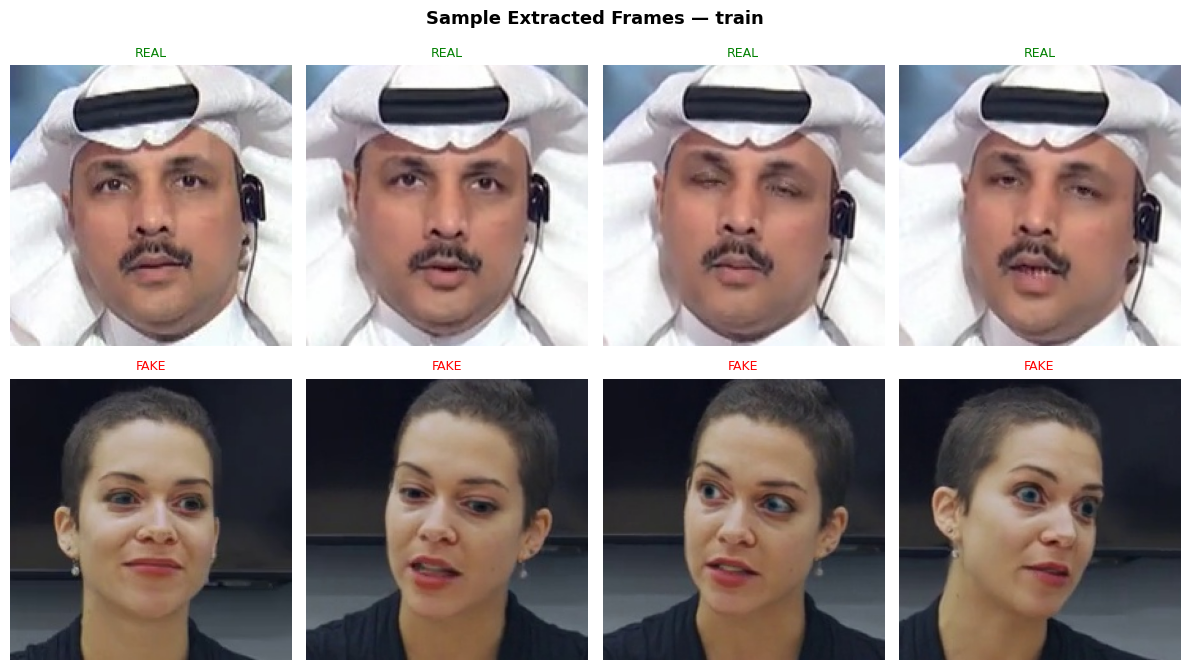

In [8]:
def show_sample_frames(split_dir, n=4):
    fig, axes = plt.subplots(2, n, figsize=(n * 3, 7))
    fig.suptitle(f"Sample Extracted Frames — {os.path.basename(split_dir)}",
                 fontsize=13, fontweight='bold')
    for row, label in enumerate(["REAL", "FAKE"]):
        cls_dir = os.path.join(split_dir, label)
        files   = sorted(os.listdir(cls_dir))[:n] if os.path.exists(cls_dir) else []
        for col in range(n):
            ax = axes[row][col]
            if col < len(files):
                img = cv2.cvtColor(
                    cv2.imread(os.path.join(cls_dir, files[col])),
                    cv2.COLOR_BGR2RGB
                )
                ax.imshow(img)
                ax.set_title(label, fontsize=9, color='green' if label=='REAL' else 'red')
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'sample_frames.png'), dpi=120, bbox_inches='tight')
    plt.show()

show_sample_frames(FF_TRAIN)

## Define DCT Preprocessing Function

Identical to Phase 13 — must match the preprocessing used during CIFAKE training so the frequency stream receives consistent input format.

In [9]:
def dct_preprocess(image):
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, (299, 299))
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)
    dct   = cv2.normalize(dct, None, 0, 1, cv2.NORM_MINMAX)
    dct   = np.stack([dct] * 3, axis=-1)
    return dct

## Define FF++ Data Generator

In [10]:
class DualStreamGenerator(Sequence):
    def __init__(self, directory, img_size=(299, 299), batch_size=16,
                 shuffle=True, class_map=None):
        self.img_size   = img_size
        self.batch_size = batch_size
        self.shuffle    = shuffle
        classes         = sorted(os.listdir(directory))
        self.class_map  = class_map or {cls: i for i, cls in enumerate(classes)}

        self.filepaths, self.labels = [], []
        for cls in classes:
            cdir = os.path.join(directory, cls)
            if not os.path.isdir(cdir):
                continue
            for f in os.listdir(cdir):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.filepaths.append(os.path.join(cdir, f))
                    self.labels.append(self.class_map[cls])

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_rgb = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        X_dct = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y     = self.labels[batch_idx].astype(np.float32)

        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                continue
            img_rgb         = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb_resized = cv2.resize(img_rgb, self.img_size).astype(np.float32) / 255.0
            X_rgb[i]        = img_rgb_resized
            X_dct[i]        = dct_preprocess(img_rgb)

        return (X_rgb, X_dct), y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


ff_train_gen = DualStreamGenerator(FF_TRAIN, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                    shuffle=True,  class_map=CLASS_MAP)
ff_test_gen  = DualStreamGenerator(FF_TEST,  img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                    shuffle=False, class_map=CLASS_MAP)

print(f"FF++ Train — REAL: {np.sum(ff_train_gen.labels==0)}  FAKE: {np.sum(ff_train_gen.labels==1)}")
print(f"FF++ Test  — REAL: {np.sum(ff_test_gen.labels==0)}   FAKE: {np.sum(ff_test_gen.labels==1)}")

FF++ Train — REAL: 8090  FAKE: 48315
FF++ Test  — REAL: 1910   FAKE: 11680


## Load Xception Dual-Stream and Configure for Adaptation

Domain adaptation freezes all layers except the top 10 of the fusion head and the top layers of each stream. This preserves CIFAKE knowledge while allowing the model to adjust decision boundaries for face-swap artifacts.

In [11]:
model = load_model(MODEL_PATH)
print("Model loaded from Phase 13.")
print(f"Total layers : {len(model.layers)}")

# Freeze everything except the top 10 layers
# This preserves the CIFAKE-trained feature representations
for layer in model.layers[:-10]:
    layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after freeze: {trainable} / {len(model.layers)}")

model.compile(
    optimizer=Adam(learning_rate=1e-6),    # Very low lr — gentle adaptation
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

I0000 00:00:1781115440.024879      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13657 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781115440.030997      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model loaded from Phase 13.
Total layers : 10
Trainable layers after freeze: 10 / 10


## Fine-Tune on FF++ C23

In [12]:
checkpoint_cb = ModelCheckpoint(
    os.path.join(CHECKPOINT_DIR, "ffpp_adapted_best.keras"),
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss", patience=4,
    restore_best_weights=True, verbose=1
)

# Create a validation split from FF++ train set
n_total  = len(ff_train_gen.filepaths)
n_val    = int(n_total * 0.2)
shuffled = np.random.permutation(n_total)

class DualStreamSubset(DualStreamGenerator):
    def __init__(self, parent, indices, batch_size=16, shuffle=True):
        self.filepaths  = parent.filepaths[indices]
        self.labels     = parent.labels[indices]
        self.img_size   = parent.img_size
        self.class_map  = parent.class_map
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)

ff_val_gen   = DualStreamSubset(ff_train_gen, shuffled[:n_val],   batch_size=BATCH_SIZE, shuffle=False)
ff_adapt_gen = DualStreamSubset(ff_train_gen, shuffled[n_val:],   batch_size=BATCH_SIZE, shuffle=True)

history_adapt = model.fit(
    ff_adapt_gen,
    validation_data=ff_val_gen,
    epochs=EPOCHS_ADAPT,
    callbacks=[checkpoint_cb, earlystop_cb]
)

model.save(os.path.join(MODEL_DIR, "ffpp_adapted_final.keras"))
print("Adapted model saved.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1781115494.847498   49145 service.cc:152] XLA service 0x7ca444025420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781115494.847537   49145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781115494.847542   49145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781115502.299469   49145 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-10 18:18:36.340881: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.344 = (f32[16,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,147,147]{3,2,1,0} %bitcast.92407, f32[128,128,1,1]{3,2,1,0} %bitcast.92414), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1/spatial_1/block2_sepconv2_1/separable_conv2d" source_file="/usr/local/lib/python3.12/dist-pac

1793/2821 ━━━━━━━━━━━━━━━━━━━━ 4:35 268ms/step - accuracy: 0.7102 - loss: 1.0680

2026-06-10 18:27:54.777978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:27:54.936764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:27:55.452330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:27:55.746388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:27:57.166985: E external/local_xla/xla/stream_

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7341 - loss: 0.9626

2026-06-10 18:35:31.511890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:35:31.655206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:35:32.414425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:35:32.547266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 18:35:33.345098: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.84026, saving model to /kaggle/working/checkpoints/ffpp_adapted_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/ffpp_adapted_best.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 1099s 345ms/step - accuracy: 0.7866 - loss: 0.7275 - val_accuracy: 0.8403 - val_loss: 0.5166
Epoch 2/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8380 - loss: 0.4753
Epoch 2: val_accuracy improved from 0.84026 to 0.85374, saving model to /kaggle/working/checkpoints/ffpp_adapted_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/ffpp_adapted_best.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 860s 305ms/step - accuracy: 0.8442 - loss: 0.4543 - val_accuracy: 0.8537 - val_loss: 0.4288
Epoch 3/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8526 - loss: 0.4201
Epoch 3: val_accuracy improved from 0.85374 to 0.85445, saving model to /kaggle/working/checkpoints/ffpp_adapted_best.keras

Epoch 3: finished saving mod

## Plot Adaptation History

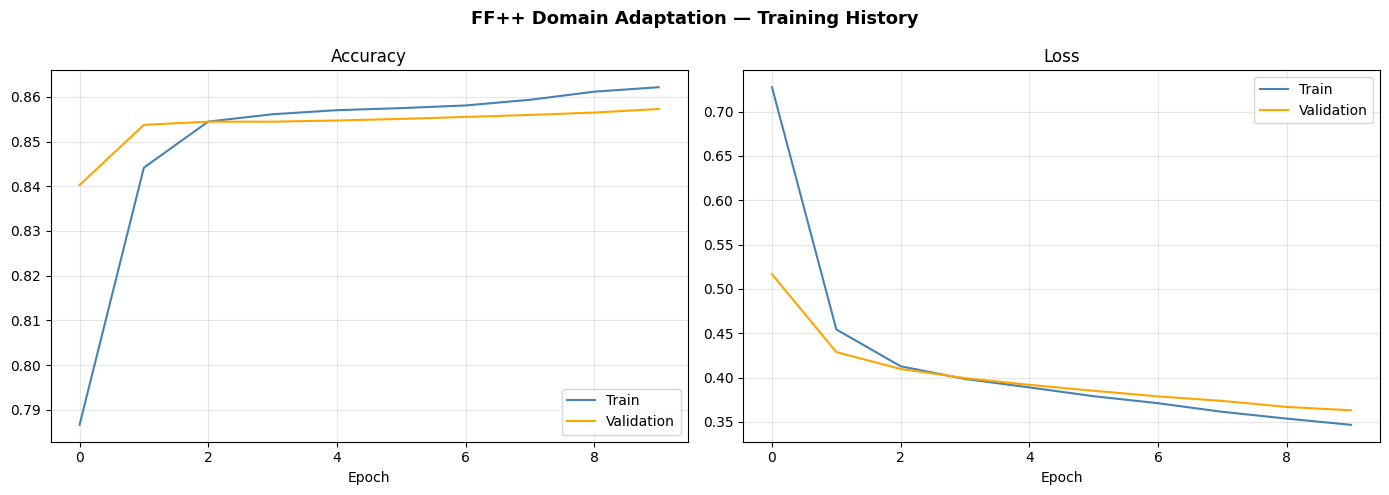

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FF++ Domain Adaptation — Training History", fontsize=13, fontweight="bold")

for ax, key, title in [
    (axes[0], "accuracy", "Accuracy"),
    (axes[1], "loss",     "Loss"),
]:
    ax.plot(history_adapt.history[key],          label="Train",      color="steelblue")
    ax.plot(history_adapt.history[f"val_{key}"], label="Validation", color="orange")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "ffpp_adaptation_history.png"), dpi=150, bbox_inches="tight")
plt.show()

## Evaluate on FF++ Test Set

2026-06-10 20:50:33.204073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 20:50:33.424826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 20:50:34.191736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 20:50:34.363713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 20:50:34.924244: E external/local_xla/xla/stream_

FF++ ADAPTED MODEL — EVALUATION RESULTS
  Accuracy      : 0.8600
  Precision     : 0.8664
  Recall        : 0.9897
  F1-Score      : 0.9240
  Specificity   : 0.0670
  AUC-ROC       : 0.7389


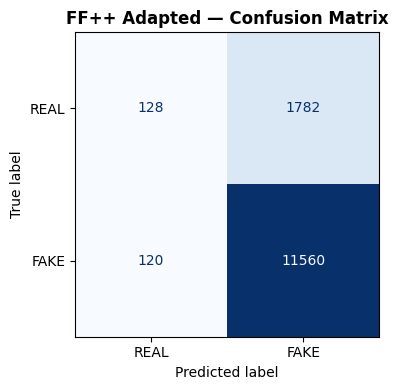

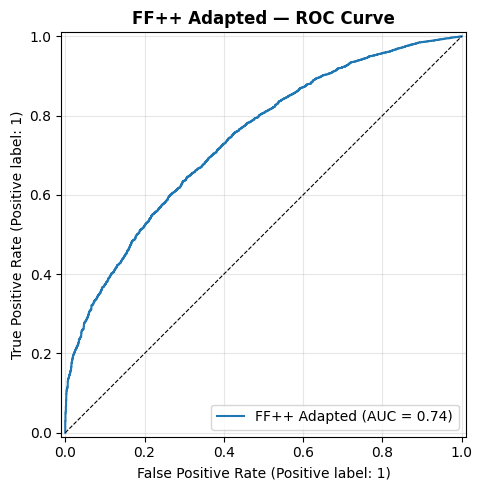

In [14]:
y_true_all, y_prob_all = [], []
for i in range(len(ff_test_gen)):
    (X_rgb_b, X_dct_b), y_b = ff_test_gen[i]
    probs = model.predict([X_rgb_b, X_dct_b], verbose=0).flatten()
    y_true_all.extend(y_b)
    y_prob_all.extend(probs)

y_true = np.array(y_true_all)
y_prob = np.array(y_prob_all)
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp)
auc  = roc_auc_score(y_true, y_prob)

FFPP_METRICS = {
    "Accuracy"    : acc,
    "Precision"   : prec,
    "Recall"      : rec,
    "F1-Score"    : f1,
    "Specificity" : spec,
    "AUC-ROC"     : auc,
}

print("=" * 50)
print("FF++ ADAPTED MODEL — EVALUATION RESULTS")
print("=" * 50)
for k, v in FFPP_METRICS.items():
    print(f"  {k:<14}: {v:.4f}")
print("=" * 50)

with open(os.path.join(RESULT_DIR, "ffpp_eval_metrics.txt"), "w") as f:
    f.write("FF++ ADAPTED MODEL — EVALUATION\n" + "="*40 + "\n")
    for k, v in FFPP_METRICS.items():
        f.write(f"  {k:<14}: {v:.4f}\n")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=["REAL", "FAKE"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("FF++ Adapted — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "ffpp_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name="FF++ Adapted")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("FF++ Adapted — ROC Curve", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "ffpp_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 14 Complete

| Component | Detail |
|---|---|
| Base model | Xception dual-stream (Phase 13) |
| Adaptation dataset | FaceForensics++ **C23** compressed |
| Video sources | original, Deepfakes, Face2Face, FaceSwap, FaceShifter, NeuralTextures, DeepFakeDetection |
| Frame extraction | `FRAMES_PER_VIDEO=10` evenly-spaced frames per video |
| Face detection | Haar cascade crop with 20 % margin |
| Train/test split | Official FF++_Metadata.csv → 80 % train / 20 % test |
| Freeze strategy | All layers except top 10 |
| Learning rate | 1e-6 (gentle — preserves CIFAKE knowledge) |
| Epochs | 10 with early stopping |
| Output | ffpp_adapted_final.keras |

**Next → Phase 15: MS COCOAI Generalization Test**

## Download Phase 14 Outputs

In [15]:
import shutil

OUTPUT_FILES = [
    os.path.join(MODEL_DIR,  "ffpp_adapted_final.keras"),
    os.path.join(RESULT_DIR, "ffpp_adaptation_history.png"),
    os.path.join(RESULT_DIR, "ffpp_confusion_matrix.png"),
    os.path.join(RESULT_DIR, "ffpp_roc_curve.png"),
    os.path.join(RESULT_DIR, "ffpp_eval_metrics.txt"),
    os.path.join(RESULT_DIR, "sample_frames.png"),
]

os.makedirs("/kaggle/working/phase_14_bundle", exist_ok=True)
for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, "/kaggle/working/phase_14_bundle/")

shutil.make_archive("/kaggle/working/phase_14_outputs", "zip", "/kaggle/working/phase_14_bundle")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / (1024 * 1024), 2) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} MB")

print()
print("Download: /kaggle/working/phase_14_outputs.zip")
print("IMPORTANT: ffpp_adapted_final.keras is required by Phase 15.")

Files packaged:
  OK       ffpp_adapted_final.keras                      192.69 MB
  OK       ffpp_adaptation_history.png                   0.08 MB
  OK       ffpp_confusion_matrix.png                     0.02 MB
  OK       ffpp_roc_curve.png                            0.05 MB
  OK       ffpp_eval_metrics.txt                         0.0 MB
  OK       sample_frames.png                             0.89 MB

Download: /kaggle/working/phase_14_outputs.zip
IMPORTANT: ffpp_adapted_final.keras is required by Phase 15.
